<a href="https://colab.research.google.com/github/aleynaerkmen/huawei-tyza-ai-bootcamp/blob/main/AleynaErkmen_credit_card_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

Hangi modeli neden seçtim?

StandardScaler:

Veri setinde kredi limitleri yüz binleri bulurken yaş bilgisi iki basamaklı sayılardan oluşuyor. Bu tarz büyük sayısal farklar, Lojistik Regresyon gibi modellerin limit sütununu gereksiz yere daha önemli sanmasına yol açabiliyor. Bunun önüne geçmek için StandardScaler kullanarak tüm sayısal sütunları aynı ölçeğe çektim ve modelin veriyi tarafsız bir şekilde öğrenmesini sağladım.

Logistic Regression:

Amacım müşterinin borcunu ödeyip ödemeyeceğini tahmin etmek olduğu için işe iki sınıflı problemlerde en sık kullanılan Lojistik Regresyon ile başladım. Hem çok hızlı çalışan hem de mantığı oldukça anlaşılır bir algoritma olduğu için projede kıyaslama yapabileceğim temel bir başlangıç modeli olarak kullandım.

Random Forest:

İnsanların harcama ve ödeme alışkanlıkları her zaman düz bir çizgi izlemez, karmaşık ilişkiler barındırır. Random Forest tek bir karar ağacına bağlı kalmak yerine yüzlerce farklı karar ağacı oluşturup ortak bir karar alıyor. Bu yöntem hem modelin veriyi ezberlemesini engelliyor hem de çok daha yüksek ve dengeli bir tahmin başarısı veriyor.

Değerlendirme Metrikleri:

Veride borcunu düzenli ödeyenlerin oranı %78 civarındayken geciktirenler %22 seviyesinde. Yani dengesiz bir dağılım var. Böyle durumlarda sadece "model %80 doğru bildi" demek hiçbir işe yaramaz. Bir banka için en tehlikeli durum borcunu ödemeyecek müşteriyi gözden kaçırmaktır. Bu yüzden riskli müşterileri ne kadar yakalayabildiğimi görmek için recall, genel ayrım gücünü ölçmek için ise ROC-AUC eğrisi ve karmaşıklık matrisi üzerinden sonuçları inceledim.

In [4]:
# Veri setini okuma işlemi
df = pd.read_csv("UCI_Credit_Card.csv")

In [5]:
# Kolaylık olması adına sütun adını daha sade hale getirme işlemi
df = df.rename(columns={'default.payment.next.month': 'default'})

In [6]:
print(f"Toplam Satır: {df.shape[0]}, Toplam Sütun: {df.shape[1]}")
print("Eksik Değer Sayısı:", df.isnull().sum().sum())
print("\nHedef Değişken Dağılımı (%):")
print(df['default'].value_counts(normalize=True) * 100)
df.head()

Toplam Satır: 30000, Toplam Sütun: 25
Eksik Değer Sayısı: 0

Hedef Değişken Dağılımı (%):
default
0    77.88
1    22.12
Name: proportion, dtype: float64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [7]:
# Eksik ve tanımsız değerleri temizleme
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print("Veri temizlendi. Toplam satır:", df.shape[0])

Veri temizlendi. Toplam satır: 30000


Veri setinde boş değer bulunmamaktadır. Ancak EDUCATION ve MARRIAGE sütunlarında veri sözlüğünde karşılığı olmayan tanımsız değerler (0, 5, 6 gibi) mantıksal olarak "Diğer" kategorisi altında toplanarak temizlenmiştir.

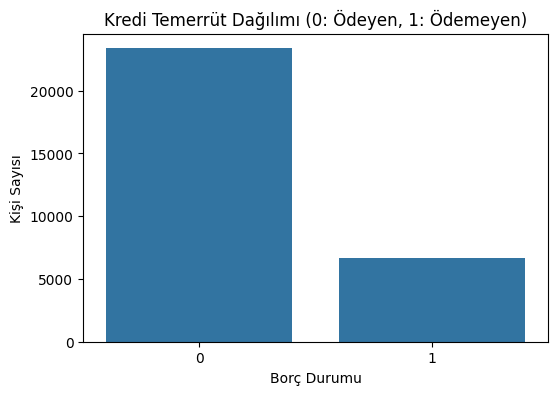

In [8]:
# 1. Grafik: Borç Ödeyenler vs Ödemeyenler
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=df)
plt.title('Kredi Temerrüt Dağılımı (0: Ödeyen, 1: Ödemeyen)')
plt.xlabel('Borç Durumu')
plt.ylabel('Kişi Sayısı')
plt.savefig('grafik_dagilim.png')
plt.show()

Modeli eğitmeden önce veri setinde borcunu düzenli ödeyenler ile geciktirenlerin dağılımına baktım. Grafikte de açıkça görüldüğü gibi, müşterilerin çok büyük bir çoğunluğu borcunu düzenli öderken, temerrüde düşenlerin oranı oldukça az. Bu dengesiz dağılım, modelin başarısını ölçerken sadece genel doğruluğa güvenmememiz gerektiğini, riskli grubu yakalama oranına odaklanmamız gerektiğini gösteriyor.

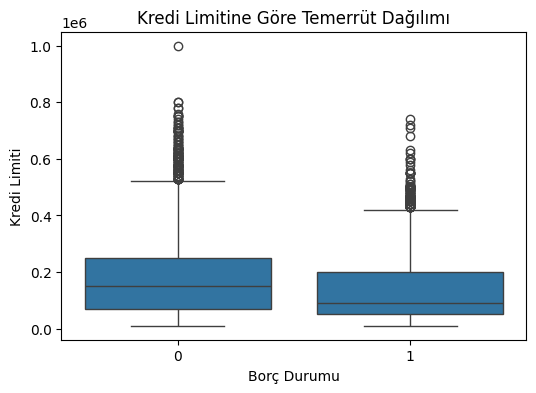

In [9]:
# 2. Grafik: Kredi Limitine Göre Dağılım
plt.figure(figsize=(6, 4))
sns.boxplot(x='default', y='LIMIT_BAL', data=df)
plt.title('Kredi Limitine Göre Temerrüt Dağılımı')
plt.xlabel('Borç Durumu')
plt.ylabel('Kredi Limiti')
plt.savefig('grafik_limit.png')
plt.show()

Kredi kartı limitinin borç ödeme üzerindeki etkisine baktığımda, limit tutarı düştükçe borcun gecikme riskinin belirgin şekilde arttığını fark ettim. Yüksek limitli müşteriler genellikle ödemelerini zamanında tamamlarken, borcunu aksatan grubun kredi limiti ortalaması çok daha düşük seviyelerde kalıyor.

In [10]:
# ID sütunu tahmin için işe yaramadığı için silindi
X = df.drop(columns=['ID', 'default'])
y = df['default']

In [11]:
# Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [12]:
# Sayısal değerleri aynı ölçeğe çekiyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Eğitim ve Test setleri hazır.")

Eğitim ve Test setleri hazır.


Tahmin üzerinde etkisi olmayan ID sütunu çıkarılmıştır. Veri %80 eğitim, %20 test olarak bölünmüş; sınıfların oranını korumak için stratify=y kullanılmıştır. Sayısal farkların modeli yanıltmasını önlemek için StandardScaler uygulanmıştır.

In [13]:
# Lojistik Regresyon
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

In [14]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

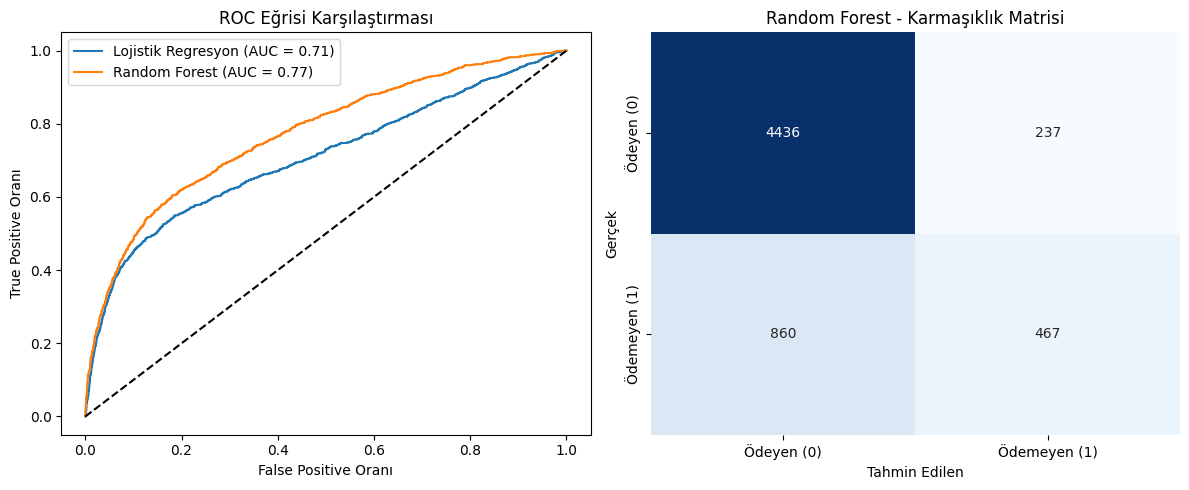

--- Random Forest Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



In [15]:
# Sonuç grafikleri
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. ROC Eğrisi Karşılaştırması
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

axes[0].plot(lr_fpr, lr_tpr, label=f'Lojistik Regresyon (AUC = {lr_auc:.2f})')
axes[0].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Eğrisi Karşılaştırması')
axes[0].set_xlabel('False Positive Oranı')
axes[0].set_ylabel('True Positive Oranı')
axes[0].legend()

# 2. Karmaşıklık Matrisi
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest - Karmaşıklık Matrisi')
axes[1].set_xlabel('Tahmin Edilen')
axes[1].set_ylabel('Gerçek')
axes[1].set_xticklabels(['Ödeyen (0)', 'Ödemeyen (1)'])
axes[1].set_yticklabels(['Ödeyen (0)', 'Ödemeyen (1)'])

plt.tight_layout()
plt.savefig('model_sonuc.png')
plt.show()

print("--- Random Forest Sınıflandırma Raporu ---")
print(classification_report(y_test, rf_preds))

İki sınıflı sınıflandırma problemimiz için temel referans model olarak lojistik regresyon, ağaç tabanlı güçlü bir alternatif olarak da random forest tercih edilmiştir. Verideki sınıf dengesizliği (%78 düzenli ödeyen, %22 geciktiren) sebebiyle yalnızca genel doğruluk oranı yerine ROC-AUC eğrisi ve karmaşıklık matrisi üzerinden değerlendirme yapılmıştır. Random forest modeli, riskli müşterileri ayırt etme gücünü gösteren ROC-AUC skorunda lojistik regresyona kıyasla daha yüksek bir performans sergilemiştir.

In [16]:
# En önemli ilk 10 değişkeni çekiyoruz
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

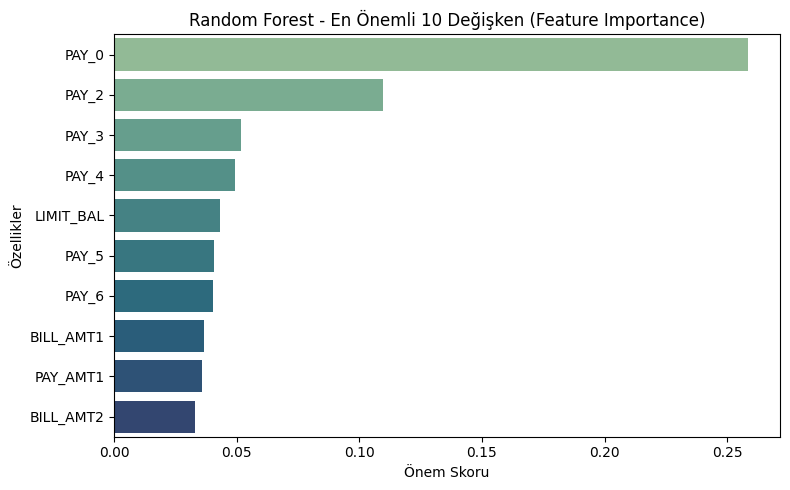

In [17]:
# Yatay bar grafiği çizdiriyoruz
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='crest', legend=False)
plt.title('Random Forest - En Önemli 10 Değişken (Feature Importance)')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellikler')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

***FEATURE IMPORTANCE VE SONUÇ ANALİZİ***

**En Kritik Faktörler:** Modelin kararlarında en etkili değişkenlerin geçmiş aylardaki ödeme gecikme durumları (PAY_0, PAY_2) olduğu görülmektedir. Bir müşterinin son aylarda ödemesini aksatıp aksatmadığı, gelecek ay temerrüde düşüp düşmeyeceğinin en güçlü sinyalidir.

**Limit ve Fatura Tutarları:** Kredi limiti (LIMIT_BAL) ve geçmiş fatura/ödeme tutarları da kararda önemli bir paya sahiptir.

**İş Çıkarımı:** Bankacılık risk yönetiminde salt demografik bilgilerden ziyade müşterinin son ödeme hareketlerine odaklanmak risk tahmin doğruluğunu doğrudan artırmaktadır.